### 약물 A, B, C, X, Y
##### 다중 분류(Multiclass Classification)
- 의학 연구원으로서 동일한 질병을 앓고 있는 일련의 환자에 대한 데이터를 수집했다.
- 치료 과정 동안 각 환자는 5가지 약물, 즉 약물 A, 약물 B, 약물 c, 약물 x 및 y 중 하나에 반응했다.
-  미래에 동일한 질병을 앓는 환자에게 어떤 약물이 적합할 수 있는지 알아보기 위한 모델을 구축한다.

##### feature
- Age: 환자의 나이
- Sex: 환자의 성별
- BP: 혈압
- Cholesterol: 콜레스테롤 수치
- Na_to_K: 나트륨-칼륨

##### target
- Drug: 의약품, 환자에게 효과가 있었던 약

In [1]:
import pandas as pd

drug_df = pd.read_csv('./datasets/drugs.csv')
drug_df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [2]:
drug_df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [3]:
drug_df.duplicated().sum()

np.int64(0)

In [4]:
drug_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


<Axes: >

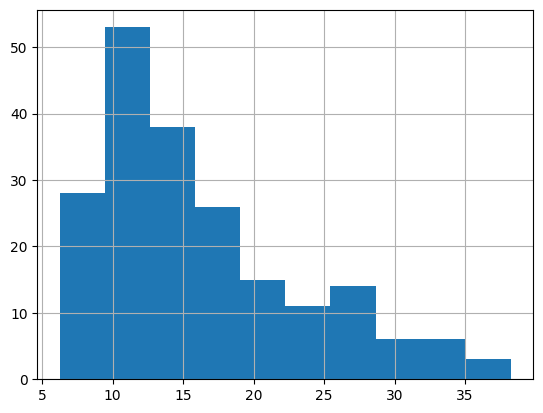

In [5]:
drug_df.Na_to_K.hist()

In [6]:
Q1 = drug_df.Na_to_K.describe().T['25%']
Q3 = drug_df.Na_to_K.describe().T['75%']

iqr = Q3 - Q1

lower_bound = iqr - 1.5 * Q1
upper_bound = iqr + 1.5 * Q3
if lower_bound < 0:
    lower_bound = 0
print(f'{lower_bound}~{upper_bound}')

0~38.0045


In [7]:
drug_df = drug_df[drug_df.Na_to_K < upper_bound].reset_index(drop=True)
drug_df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
194,56,F,LOW,HIGH,11.567,drugC
195,16,M,LOW,HIGH,12.006,drugC
196,52,M,NORMAL,HIGH,9.894,drugX
197,23,M,NORMAL,NORMAL,14.020,drugX


In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

bp_encoder = OneHotEncoder(sparse_output=False)
bp_onehot = bp_encoder.fit_transform(drug_df[['BP']])
bp_cols = bp_encoder.get_feature_names_out(['BP'])
bp_onehot_df = pd.DataFrame(data=bp_onehot, columns=bp_cols)
drug_enc_df = pd.concat([drug_df.iloc[:, :-1], bp_onehot_df], axis=1)
drug_enc_df['Drug'] = drug_df.Drug

gender_encoder = LabelEncoder()
genders = gender_encoder.fit_transform(drug_df.Sex.tolist())
drug_enc_df['Sex'] = genders

cholesterol_encoder = LabelEncoder()
cholesterols = cholesterol_encoder.fit_transform(drug_df.Cholesterol.tolist())
drug_enc_df['Cholesterol'] = cholesterols

drug_encoder = LabelEncoder()
drugs = drug_encoder.fit_transform(drug_df.Drug.tolist())
drug_enc_df['Drug'] = drugs

In [9]:
drug_enc_df = drug_enc_df.drop(['BP'], axis=1)
drug_enc_df

,Age,Sex,Cholesterol,Na_to_K,BP_HIGH,BP_LOW,BP_NORMAL,Drug
0,23,0,0,25.355,1.0,0.0,0.0,4
1,47,1,0,13.093,0.0,1.0,0.0,2
2,47,1,0,10.114,0.0,1.0,0.0,2
3,28,0,0,7.798,0.0,0.0,1.0,3
4,61,0,0,18.043,0.0,1.0,0.0,4
...,...,...,...,...,...,...,...,...
194,56,0,0,11.567,0.0,1.0,0.0,2
195,16,1,0,12.006,0.0,1.0,0.0,2
196,52,1,0,9.894,0.0,0.0,1.0,3
197,23,1,1,14.020,0.0,0.0,1.0,3


In [10]:
drug_enc_df.Drug.value_counts()

Drug
4    90
3    54
0    23
2    16
1    16
Name: count, dtype: int64

In [11]:
print(drug_encoder.classes_)
print(gender_encoder.classes_)
print(bp_encoder.categories_)
print(cholesterol_encoder.classes_)

['drugA' 'drugB' 'drugC' 'drugX' 'drugY']
['F' 'M']
[array(['HIGH', 'LOW', 'NORMAL'], dtype=object)]
['HIGH' 'NORMAL']


In [12]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

feature = drug_enc_df.iloc[:, :-1]
target = drug_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, 
                 target, 
                 test_size=0.2, 
                 stratify=target, 
                 random_state=124)

dtc = DecisionTreeClassifier()

parameters = {
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 20)
}

random_cv = RandomizedSearchCV(
    dtc,
    param_distributions=parameters,
    n_iter=4,
    cv=5,
    refit=True,
    return_train_score=True,
    random_state=124
)

random_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'max_depth': <scipy.stats....00241DDC9BDC0>, 'min_samples_split': <scipy.stats....00241BFB036D0>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [13]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
0,"{'max_depth': 8, 'min_samples_split': 19}",0.987298,1
1,"{'max_depth': 9, 'min_samples_split': 4}",0.987298,1
3,"{'max_depth': 6, 'min_samples_split': 16}",0.987298,1
2,"{'max_depth': 3, 'min_samples_split': 2}",0.874597,4


In [15]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

feature = drug_enc_df.iloc[:, :-1]
target = drug_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, 
                 target, 
                 test_size=0.2, 
                 stratify=target, 
                 random_state=124)

dtc = DecisionTreeClassifier(random_state = 124)

parameters = {
    'max_depth' : list(range(3, 10)),
    'min_samples_split': list(range(2, 20))
}

grid_cv = GridSearchCV(
    dtc,
    param_grid=parameters,
    cv=5,
    refit=True,
    return_train_score=True,
)

grid_cv.fit(X_train, y_train)

,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [18]:
grid_cv_scores = pd.DataFrame(grid_cv.cv_results_)
grid_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').tail(30)

,params,mean_test_score,rank_test_score
120,"{'max_depth': 9, 'min_samples_split': 14}",0.987298,1
121,"{'max_depth': 9, 'min_samples_split': 15}",0.987298,1
114,"{'max_depth': 9, 'min_samples_split': 8}",0.987298,1
115,"{'max_depth': 9, 'min_samples_split': 9}",0.987298,1
116,"{'max_depth': 9, 'min_samples_split': 10}",0.987298,1
117,"{'max_depth': 9, 'min_samples_split': 11}",0.987298,1
118,"{'max_depth': 9, 'min_samples_split': 12}",0.987298,1
119,"{'max_depth': 9, 'min_samples_split': 13}",0.987298,1
124,"{'max_depth': 9, 'min_samples_split': 18}",0.987298,1
125,"{'max_depth': 9, 'min_samples_split': 19}",0.987298,1


In [20]:
dtc = grid_cv.best_estimator_
dtc.feature_importances_

array([0.13649421, 0.        , 0.11753668, 0.47435852, 0.20864452,
       0.06296608, 0.        ])

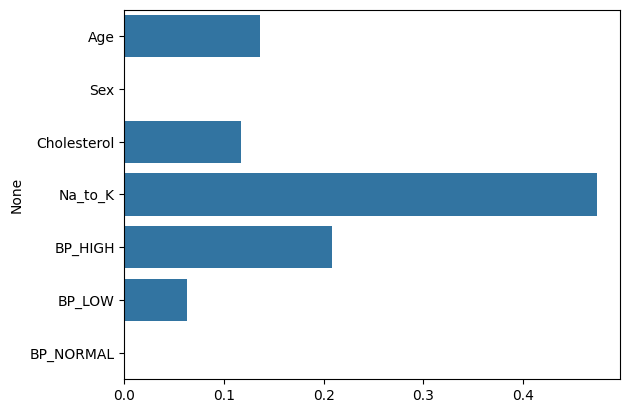

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature.columns)
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Classifier의 Decision Boundary를 시각화 하는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X.values, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow',
                           zorder=1)

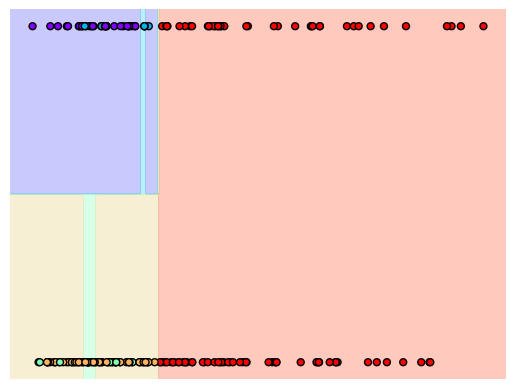

In [26]:
visualize_boundary(dtc, feature[["Na_to_K", "BP_HIGH"]], target)

In [27]:
dtc = DecisionTreeClassifier(max_depth=3, min_samples_leaf=17, random_state=124)

feature, target = drug_enc_df.iloc[:, :-1], drug_enc_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

dtc.fit(X_train.values, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,17
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,124
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


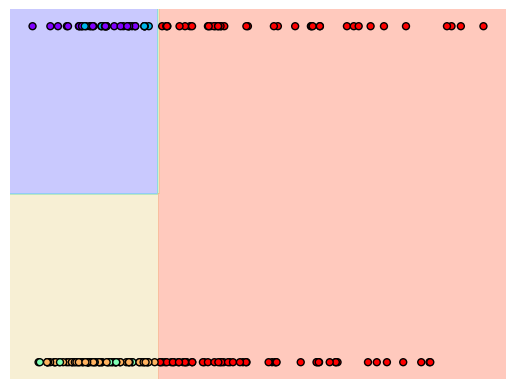

In [28]:
# 과소적합
visualize_boundary(dtc, feature[["Na_to_K", "BP_HIGH"]], target)